## Introduction
This notebook provides a comprehensive guide to auditing skeletons generated from motion capture data. It includes functionalities to load CSV files containing the skeleton data, extract the 3D positions of relevant bones, calculate specific measurements (such as shoulder width, arm lengths, leg lengths, and overall height), and visualize the bone positions in 3D space.

The notebook is designed to compare the generated skeletons with manual human (tape-based) measurements, allowing for an accurate assessment of the data's quality and consistency.

This notebook, inluding code was generated with ChatGPTs code interpreter. To see this process look here https://chat.openai.com/share/b2772194-61dc-45ff-bd64-c4eba589cb58.

### Measurements Calculated
- **Shoulder Width**: Distance between the left and right upper arms.
- **Upper Arm Length (Left & Right)**: Distance between the upper arm and lower arm.
- **Lower Arm Length (Left & Right)**: Distance between the lower arm and hand.
- **Upper Leg Length (Left & Right)**: Distance between the thigh and shin.
- **Lower Leg Length (Left & Right)**: Distance between the shin and foot.
- **Overall Height**: Average of the distances from the left and right feet to the head.

### Data Structure
The expected CSV file structure includes the following rows:
- 1st row: General information about the take and export settings.
- 3rd row: Data type (e.g., bone) for each corresponding column.
- 4th row: Marker or asset labels (bone names).
- 6th and 7th row: Header label for the data included in the column (position and orientation on X/Y/Z).
- Subsequent rows: Frame data with X/Y/Z positions and W/X/Y/Z rotation quaternion for each bone.

**Note**: The coordinate system and units used in the CSV files should be consistent with the visualization and measurement calculation within this notebook. Adjustments may be needed based on the specific coordinate system used in the motion capture setup.

Let's start by loading the CSV files and extracting the relevant data.


In [1]:
# Importing required libraries
import csv

# Function to extract bone names and position data from the CSV file
def extract_bone_data(file_path):
    bone_names = []
    frames_data = []
    with open(file_path, 'r') as file:
        # Skip the first 3 rows
        for _ in range(3):
            file.readline()
        # Read the 4th row to extract the bone names corresponding to the position columns (every 7th starting from 6th)
        bone_names_line = file.readline().strip().split(",")
        bone_names = [bone_names_line[i] for i in range(6, len(bone_names_line), 7)]
        # Skip rows 5, 6, and 7
        for _ in range(3):
            file.readline()
        # Iterate through the remaining rows to extract position data for each frame
        for line in file:
            frame_data = line.strip().split(",")
            # Extract X, Y, Z position data for each bone (every 7th starting from 6th)
            positions = [(float(frame_data[i]), float(frame_data[i + 1]), float(frame_data[i + 2])) for i in range(6, len(frame_data), 7)]
            frames_data.append(positions)
    return bone_names, frames_data

# Path to the CSV file containing the skeleton data
file_path = "Test_Data/0-10/M-SMC-06262023-01.csv"  # Update this path

# Extracting bone names and position data
bone_names, frames_data = extract_bone_data(file_path)

# Displaying the bone names and the corresponding XYZ positions for the first frame
bone_names_and_positions_first_frame = list(zip(bone_names, frames_data[0]))
bone_names_and_positions_first_frame


[('SMC-06262023-01:Hip', (-58.573296, 890.913696, -289.223877)),
 ('SMC-06262023-01:Ab', (-70.900574, 985.19574, -300.188568)),
 ('SMC-06262023-01:Chest', (-89.535187, 1204.60437, -376.464142)),
 ('SMC-06262023-01:Neck', (-106.369324, 1387.781616, -429.715607)),
 ('SMC-06262023-01:Head', (-104.214577, 1483.816895, -387.916595)),
 ('SMC-06262023-01:LShoulder', (-68.746849, 1382.253662, -423.479492)),
 ('SMC-06262023-01:LUArm', (-10.68696, 1354.534424, -383.657654)),
 ('SMC-06262023-01:LFArm', (28.616932, 1105.712524, -190.386749)),
 ('SMC-06262023-01:LHand', (-33.528263, 1009.610901, 20.518034)),
 ('SMC-06262023-01:RShoulder', (-140.339355, 1371.501587, -437.833008)),
 ('SMC-06262023-01:RUArm', (-204.07515, 1331.059692, -432.608398)),
 ('SMC-06262023-01:RFArm', (-334.153259, 1062.248657, -324.760986)),
 ('SMC-06262023-01:RHand', (-243.695206, 1096.128662, -105.106888)),
 ('SMC-06262023-01:LThigh', (31.01449, 904.676025, -271.607117)),
 ('SMC-06262023-01:LShin', (125.576485, 499.487885, 

### Euclidean distance measurements

In [2]:
# Function to calculate Euclidean distance between two points
def calculate_distance(bone1, bone2, positions):
    x1, y1, z1 = positions[bone_names.index(bone1)]
    x2, y2, z2 = positions[bone_names.index(bone2)]
    return ((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2) ** 0.5

# Measurements to be calculated (Update the bone names according to the specific naming convention in your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]
measurements = {
    # "Shoulder Width": (f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:RUArm"),
    "Shoulder Width": (f"{skeleton_identifier}:LShoulder", f"{skeleton_identifier}:RShoulder"),
    "Upper Arm Length (Left)": (f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:LFArm"),
    "Lower Arm Length (Left)": (f"{skeleton_identifier}:LFArm", f"{skeleton_identifier}:LHand"),
    "Upper Arm Length (Right)": (f"{skeleton_identifier}:RUArm", f"{skeleton_identifier}:RFArm"),
    "Lower Arm Length (Right)": (f"{skeleton_identifier}:RFArm", f"{skeleton_identifier}:RHand"),
    "Upper Leg Length (Left)": (f"{skeleton_identifier}:LThigh", f"{skeleton_identifier}:LShin"),
    "Lower Leg Length (Left)": (f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LFoot"),
    "Upper Leg Length (Right)": (f"{skeleton_identifier}:RThigh", f"{skeleton_identifier}:RShin"),
    "Lower Leg Length (Right)": (f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RFoot"),
}

# Calculating the measurements for the first 10 frames
all_frame_measurements = []
for frame_positions in frames_data[:10]:
    frame_measurements = {name: calculate_distance(bone1, bone2, frame_positions) for name, (bone1, bone2) in measurements.items()}
    # Calculating overall height (average of Left and Right Feet to Head)
    frame_measurements["Overall Height"] = (calculate_distance(f"{skeleton_identifier}:Head", f"{skeleton_identifier}:LFoot", frame_positions) +
                                            calculate_distance(f"{skeleton_identifier}:Head", f"{skeleton_identifier}:RFoot", frame_positions)) / 2
    all_frame_measurements.append(frame_measurements)

all_frame_measurements



[{'Shoulder Width': 73.80458965218845,
  'Upper Arm Length (Left)': 317.507128369548,
  'Lower Arm Length (Left)': 239.9549430561897,
  'Upper Arm Length (Right)': 317.5070885096659,
  'Lower Arm Length (Right)': 239.95507258556637,
  'Upper Leg Length (Left)': 423.27220509591416,
  'Lower Leg Length (Left)': 408.8311867255595,
  'Upper Leg Length (Right)': 423.2719270094128,
  'Lower Leg Length (Right)': 408.8310346829681,
  'Overall Height': 1434.957259843359},
 {'Shoulder Width': 73.80458965218845,
  'Upper Arm Length (Left)': 317.507128369548,
  'Lower Arm Length (Left)': 239.95498475783052,
  'Upper Arm Length (Right)': 317.5069979210709,
  'Lower Arm Length (Right)': 239.95506704639175,
  'Upper Leg Length (Left)': 423.27210812045274,
  'Lower Leg Length (Left)': 408.83109821183075,
  'Upper Leg Length (Right)': 423.272049882845,
  'Lower Leg Length (Right)': 408.83109399946244,
  'Overall Height': 1434.9572588093688},
 {'Shoulder Width': 73.80455775656154,
  'Upper Arm Length (L

### Accumulate using numpy

In [3]:
# Import necessary libraries
import numpy as np

# Function to calculate Euclidean distance between two points
def calculate_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2 + (point1[2] - point2[2]) ** 2)

# Function to calculate accumulated distance between a list of bones
def calculate_accumulated_distance(bones, positions):
    distance = 0
    for i in range(len(bones) - 1):
        distance += calculate_distance(positions[bone_names.index(bones[i])], positions[bone_names.index(bones[i + 1])])
    return distance

# Bones of interest (Update these according to the specific naming convention in your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Define lists of bones for accumulated measurements
shoulder_bones = [f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:RUArm"]
height_bones = [f"{skeleton_identifier}:RFoot", f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RThigh", f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:Ab", f"{skeleton_identifier}:Head"]
leg_bones_left = [f"{skeleton_identifier}:LFoot", f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LThigh"]
leg_bones_right = [f"{skeleton_identifier}:RFoot", f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RThigh"]
arm_bones_left = [f"{skeleton_identifier}:LHand", f"{skeleton_identifier}:LFArm", f"{skeleton_identifier}:LUArm"]
arm_bones_right = [f"{skeleton_identifier}:RHand", f"{skeleton_identifier}:RFArm", f"{skeleton_identifier}:RUArm"]

# Example: Calculating the accumulated distances for the first frame
frame_positions = frames_data[0]
shoulder_width_accumulated = calculate_accumulated_distance(shoulder_bones, frame_positions)
total_height_accumulated = calculate_accumulated_distance(height_bones, frame_positions)
total_leg_length_accumulated_left = calculate_accumulated_distance(leg_bones_left, frame_positions)
total_leg_length_accumulated_right = calculate_accumulated_distance(leg_bones_right, frame_positions)
total_arm_length_accumulated_left = calculate_accumulated_distance(arm_bones_left, frame_positions)
total_arm_length_accumulated_right = calculate_accumulated_distance(arm_bones_right, frame_positions)

# Print the calculated measurements for verification
measurements_accumulated = {
    "Shoulder Width (Accumulated)": shoulder_width_accumulated,
    "Total Height (Accumulated)": total_height_accumulated,
    "Total Leg Length (Accumulated, Left)": total_leg_length_accumulated_left,
    "Total Leg Length (Accumulated, Right)": total_leg_length_accumulated_right,
    "Total Arm Length (Accumulated, Left)": total_arm_length_accumulated_left,
    "Total Arm Length (Accumulated, Right)": total_arm_length_accumulated_right,
}
measurements_accumulated


{'Shoulder Width (Accumulated)': 200.86371103835918,
 'Total Height (Accumulated)': 1527.5271287408827,
 'Total Leg Length (Accumulated, Left)': 832.1033918214737,
 'Total Leg Length (Accumulated, Right)': 832.1029616923809,
 'Total Arm Length (Accumulated, Left)': 557.4620714257377,
 'Total Arm Length (Accumulated, Right)': 557.4621610952322}

In [4]:
# Function to calculate measurements for multiple frames
def calculate_measurements_for_frames(frames_data, bone_names):
    # Update these bone names according to your specific naming convention
    skeleton_identifier = bone_names[0].split(":")[0]
    left_shoulder = f"{skeleton_identifier}:LShoulder"
    right_shoulder = f"{skeleton_identifier}:RShoulder"
    
    # Calculating the measurements for each frame
    all_frame_measurements = []
    for frame_positions in frames_data:
        # Distance from left shoulder to right shoulder
        shoulder_width = calculate_distance(frame_positions[bone_names.index(left_shoulder)], frame_positions[bone_names.index(right_shoulder)])
        
        # Add other measurements as needed
        frame_measurements = {
            "Shoulder Width": shoulder_width,
            # Add other measurements here...
        }
        all_frame_measurements.append(frame_measurements)
    
    return all_frame_measurements

# Calculating the measurements for the first 10 frames and printing them
measurements_first_10_frames = calculate_measurements_for_frames(frames_data[:10], bone_names)
measurements_first_10_frames


[{'Shoulder Width': 73.80458965218845},
 {'Shoulder Width': 73.80458965218845},
 {'Shoulder Width': 73.80455775656154},
 {'Shoulder Width': 73.80460566682491},
 {'Shoulder Width': 73.80462931502774},
 {'Shoulder Width': 73.80464010412969},
 {'Shoulder Width': 73.80463281148275},
 {'Shoulder Width': 73.80460585057929},
 {'Shoulder Width': 73.8045800686518},
 {'Shoulder Width': 73.80463402772587}]

In [5]:
# Function to calculate measurements for multiple frames
def calculate_measurements_for_frames(frames_data, bone_names):
    # Update these bone names according to your specific naming convention
    skeleton_identifier = bone_names[0].split(":")[0]
    left_shoulder = f"{skeleton_identifier}:LUArm"
    right_shoulder = f"{skeleton_identifier}:RUArm"
    # neck = f"{skeleton_identifier}:Neck"  # Update this if different
    # neck = f"{skeleton_identifier}:Chest"  # Update this if different
    neck = f"{skeleton_identifier}:Head"  # Update this if different

    # Calculating the measurements for each frame
    all_frame_measurements = []
    for frame_positions in frames_data:
        # Distance from shoulders to neck
        left_shoulder_to_neck = calculate_distance(frame_positions[bone_names.index(left_shoulder)], frame_positions[bone_names.index(neck)])
        right_shoulder_to_neck = calculate_distance(frame_positions[bone_names.index(right_shoulder)], frame_positions[bone_names.index(neck)])
        
        # Accumulated shoulder width: sum of left and right shoulder-to-neck distances
        shoulder_width_accumulated = left_shoulder_to_neck + right_shoulder_to_neck
        
        # Add other measurements as needed
        frame_measurements = {
            "Shoulder Width (Accumulated)": shoulder_width_accumulated,
            # Add other measurements here...
        }
        all_frame_measurements.append(frame_measurements)
    
    return all_frame_measurements

# Calculating the measurements for the first 10 frames and printing them
measurements_first_10_frames = calculate_measurements_for_frames(frames_data[:10], bone_names)
measurements_first_10_frames


[{'Shoulder Width (Accumulated)': 347.5172916610171},
 {'Shoulder Width (Accumulated)': 347.51729204220874},
 {'Shoulder Width (Accumulated)': 450.7672367374862},
 {'Shoulder Width (Accumulated)': 448.91636094223315},
 {'Shoulder Width (Accumulated)': 436.84793473430767},
 {'Shoulder Width (Accumulated)': 427.06363251844084},
 {'Shoulder Width (Accumulated)': 434.68574463184655},
 {'Shoulder Width (Accumulated)': 437.87870925960044},
 {'Shoulder Width (Accumulated)': 439.2962552932237},
 {'Shoulder Width (Accumulated)': 439.43234077287707}]

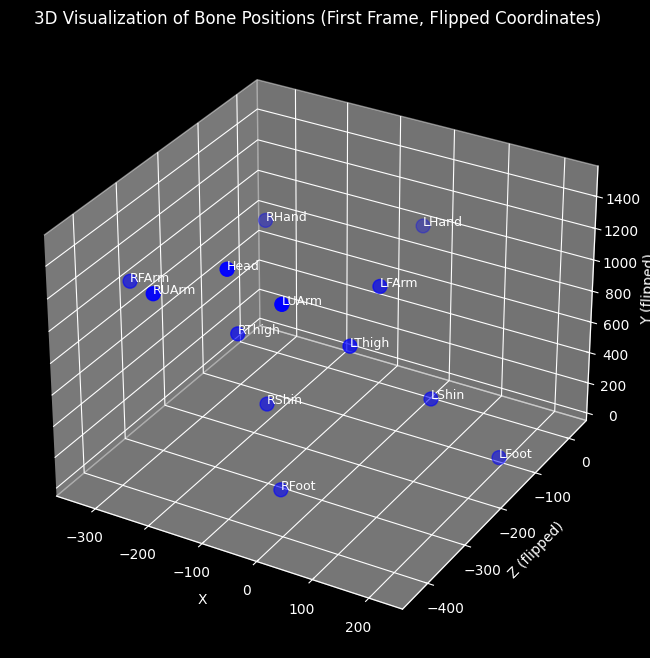

In [6]:
# Importing required libraries for visualization
%matplotlib inline
# %matplotlib notebook
# %matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Bones of interest (update these according to the specific naming convention in your CSV file)
bones_of_interest = [
    f"{skeleton_identifier}:Head",
    f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:RUArm",
    f"{skeleton_identifier}:LFArm", f"{skeleton_identifier}:RFArm",
    f"{skeleton_identifier}:LHand", f"{skeleton_identifier}:RHand",
    f"{skeleton_identifier}:LThigh", f"{skeleton_identifier}:RThigh",
    f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:RShin",
    f"{skeleton_identifier}:LFoot", f"{skeleton_identifier}:RFoot",
]

# Function to plot the bone positions for the given frame with flipped Y and Z coordinates
def plot_bone_positions_flipped(frame_positions):
    # Extracting the X, Y, Z coordinates for the selected bones (with flipped Y and Z)
    x_values = [frame_positions[bone_names.index(bone)][0] for bone in bones_of_interest]
    y_values = [frame_positions[bone_names.index(bone)][2] for bone in bones_of_interest]
    z_values = [frame_positions[bone_names.index(bone)][1] for bone in bones_of_interest]
    # Plotting the 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_values, y_values, z_values, c='blue', s=100)
    for i, bone_name in enumerate(bones_of_interest):
        ax.text(x_values[i], y_values[i], z_values[i], bone_name.split(":")[-1], fontsize=9)
    ax.set_xlabel('X')
    ax.set_ylabel('Z (flipped)')
    ax.set_zlabel('Y (flipped)')
    plt.title('3D Visualization of Bone Positions (First Frame, Flipped Coordinates)')
    plt.show()

# Plotting the bone positions for the first frame with flipped Y and Z coordinates
plot_bone_positions_flipped(frames_data[0])



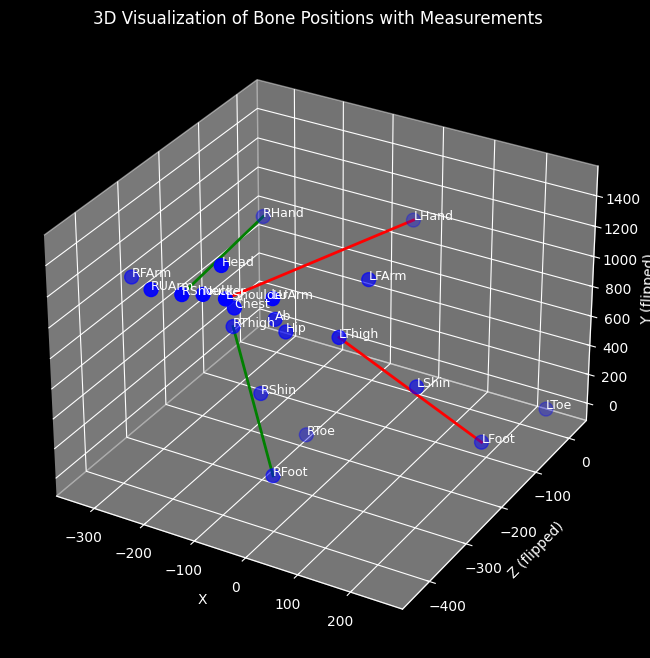

In [7]:
# Import necessary libraries
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to plot the bone positions and measurements
def plot_bone_positions_and_measurements(frame_positions, bone_names):
    # Extracting the X, Y, Z coordinates
    x_values = [pos[0] for pos in frame_positions]
    y_values = [pos[2] for pos in frame_positions]  # Flipping Y and Z
    z_values = [pos[1] for pos in frame_positions]  # Flipping Y and Z
    
    # Plotting the 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_values, y_values, z_values, c='blue', s=100)
    for i, bone_name in enumerate(bone_names):
        ax.text(x_values[i], y_values[i], z_values[i], bone_name.split(":")[-1], fontsize=9)
    
    # Drawing measurements: Leg Length
    for side, color in [("L", "r"), ("R", "g")]:
        hip = f"{skeleton_identifier}:{side}Thigh"
        foot = f"{skeleton_identifier}:{side}Foot"
        ax.plot([frame_positions[bone_names.index(hip)][0], frame_positions[bone_names.index(foot)][0]],
                [frame_positions[bone_names.index(hip)][2], frame_positions[bone_names.index(foot)][2]],
                [frame_positions[bone_names.index(hip)][1], frame_positions[bone_names.index(foot)][1]],
                color=color, linewidth=2)
    
    # Drawing measurements: Arm Length
    for side, color in [("L", "r"), ("R", "g")]:
        shoulder = f"{skeleton_identifier}:{side}Shoulder"
        hand = f"{skeleton_identifier}:{side}Hand"
        ax.plot([frame_positions[bone_names.index(shoulder)][0], frame_positions[bone_names.index(hand)][0]],
                [frame_positions[bone_names.index(shoulder)][2], frame_positions[bone_names.index(hand)][2]],
                [frame_positions[bone_names.index(shoulder)][1], frame_positions[bone_names.index(hand)][1]],
                color=color, linewidth=2)
    
    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Z (flipped)')
    ax.set_zlabel('Y (flipped)')
    plt.title('3D Visualization of Bone Positions with Measurements')
    plt.show()

# Skeleton identifier (update according to your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Plotting the bone positions and measurements for the first frame
plot_bone_positions_and_measurements(frames_data[0], bone_names)


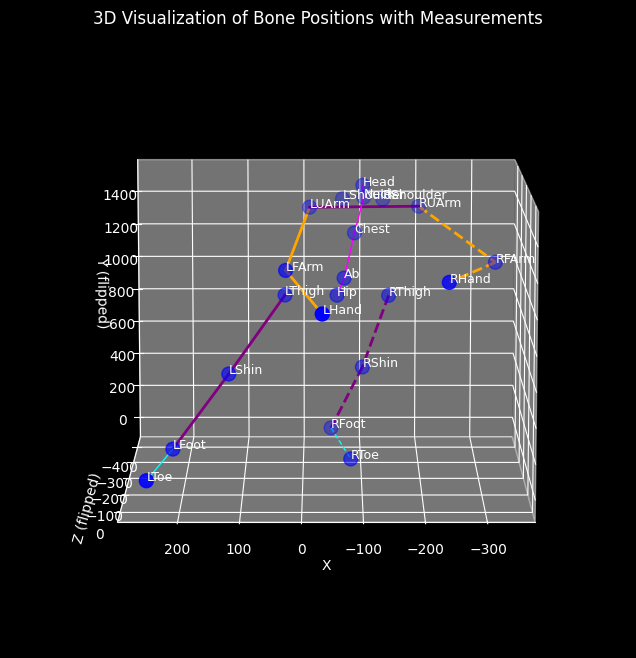

In [8]:
# Function to plot the bone positions and measurements
def plot_bone_positions_and_measurements(frame_positions, bone_names):
    # Extracting the X, Y, Z coordinates
    x_values = [pos[0] for pos in frame_positions]
    y_values = [pos[2] for pos in frame_positions]  # Flipping Y and Z
    z_values = [pos[1] for pos in frame_positions]  # Flipping Y and Z
    
    # Plotting the 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_values, y_values, z_values, c='blue', s=100)
    for i, bone_name in enumerate(bone_names):
        ax.text(x_values[i], y_values[i], z_values[i], bone_name.split(":")[-1], fontsize=9)
    
    # Drawing measurements: Leg and Arm sections
    for side, color, linestyle in [("L", "r", "-"), ("R", "g", "--")]:
        leg_bones = [f"{skeleton_identifier}:{side}Thigh", f"{skeleton_identifier}:{side}Shin", f"{skeleton_identifier}:{side}Foot"]
        arm_bones = [f"{skeleton_identifier}:{side}UArm", f"{skeleton_identifier}:{side}FArm", f"{skeleton_identifier}:{side}Hand"]  # Excluding shoulder
        for bones, c in zip([leg_bones, arm_bones], ["purple", "orange"]):
            for b1, b2 in zip(bones[:-1], bones[1:]):
                ax.plot([frame_positions[bone_names.index(b1)][0], frame_positions[bone_names.index(b2)][0]],
                        [frame_positions[bone_names.index(b1)][2], frame_positions[bone_names.index(b2)][2]],
                        [frame_positions[bone_names.index(b1)][1], frame_positions[bone_names.index(b2)][1]],
                        color=c, linestyle=linestyle, linewidth=2)
    
    # Drawing measurements: Shoulder Width
    l_uarm = f"{skeleton_identifier}:LUArm"  # Using upper arm for stability
    r_uarm = f"{skeleton_identifier}:RUArm"  # Using upper arm for stability
    ax.plot([frame_positions[bone_names.index(l_uarm)][0], frame_positions[bone_names.index(r_uarm)][0]],
            [frame_positions[bone_names.index(l_uarm)][2], frame_positions[bone_names.index(r_uarm)][2]],
            [frame_positions[bone_names.index(l_uarm)][1], frame_positions[bone_names.index(r_uarm)][1]],
            color="purple", linewidth=2)
    
    # Drawing the upper body line: Head-Neck-Chest-Ab-Hip
    upper_body_bones = [f"{skeleton_identifier}:Head", f"{skeleton_identifier}:Neck", f"{skeleton_identifier}:Chest", f"{skeleton_identifier}:Ab", f"{skeleton_identifier}:Hip"]  # Including Neck
    for b1, b2 in zip(upper_body_bones[:-1], upper_body_bones[1:]):
        ax.plot([frame_positions[bone_names.index(b1)][0], frame_positions[bone_names.index(b2)][0]],
                [frame_positions[bone_names.index(b1)][2], frame_positions[bone_names.index(b2)][2]],
                [frame_positions[bone_names.index(b1)][1], frame_positions[bone_names.index(b2)][1]],
                color="magenta", linewidth=1)
    
    # Drawing lines from Foot to Toe for both sides
    for side, color, linestyle in [("L", "cyan", "-"), ("R", "cyan", "--")]:
        foot = f"{skeleton_identifier}:{side}Foot"
        toe = f"{skeleton_identifier}:{side}Toe"
        ax.plot([frame_positions[bone_names.index(foot)][0], frame_positions[bone_names.index(toe)][0]],
                [frame_positions[bone_names.index(foot)][2], frame_positions[bone_names.index(toe)][2]],
                [frame_positions[bone_names.index(foot)][1], frame_positions[bone_names.index(toe)][1]],
                color=color,  linestyle=linestyle, linewidth=1)
        
    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Z (flipped)')
    ax.set_zlabel('Y (flipped)')
    ax.view_init(azim=90, elev=10)  # Rotate view and set a more frontal perspective
    plt.title('3D Visualization of Bone Positions with Measurements')
    plt.show()

# Skeleton identifier (update according to your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Plotting the bone positions and measurements for the first frame
plot_bone_positions_and_measurements(frames_data[0], bone_names)


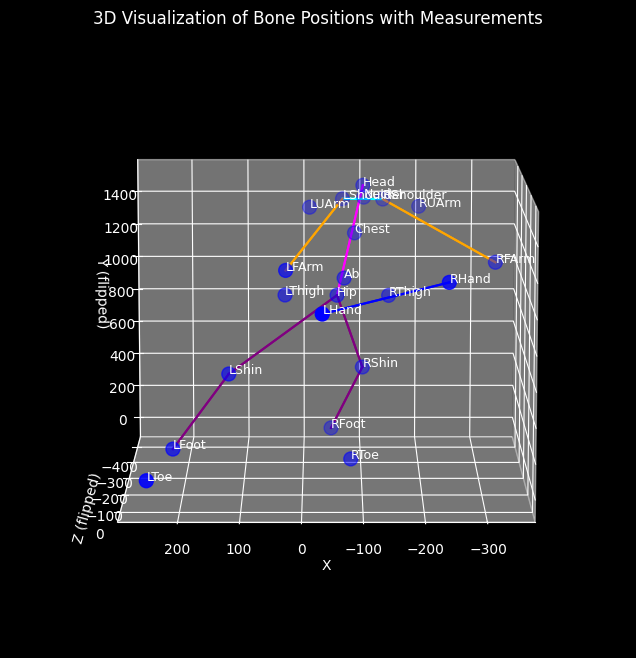

In [9]:
# Function to plot the bone positions and measurements (wrong way to do this)
def plot_bone_positions_and_measurements(frame_positions, bone_names):
    # Extracting the X, Y, Z coordinates
    x_values = [pos[0] for pos in frame_positions]
    y_values = [pos[2] for pos in frame_positions]  # Flipping Y and Z
    z_values = [pos[1] for pos in frame_positions]  # Flipping Y and Z
    
    # Plotting the 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_values, y_values, z_values, c='blue', s=100)
    for i, bone_name in enumerate(bone_names):
        ax.text(x_values[i], y_values[i], z_values[i], bone_name.split(":")[-1], fontsize=9)

    # 1. Standing Height: Head-Hip + Leg Length
    upper_body_bones = [f"{skeleton_identifier}:Head", f"{skeleton_identifier}:Hip"]
    leg_bones_L = [f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LFoot"]
    leg_bones_R = [f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RFoot"]
    
    # 2. Wingspan: LHand-RHand
    wingspan_bones = [f"{skeleton_identifier}:LHand", f"{skeleton_identifier}:RHand"]
    
    # 3. Sitting Height: Head-Hip
    # (Use upper_body_bones)
    
    # 4. Upper Leg Length: Hip-Shin
    # (Use the first two bones of leg_bones_L or leg_bones_R)
    
    # 5. Biacromial Breadth: LShoulder-RShoulder
    biacromial_bones = [f"{skeleton_identifier}:LShoulder", f"{skeleton_identifier}:RShoulder"]
    
    # 6. Upper Arm Length: Shoulder-UArm
    upper_arm_bones_L = [f"{skeleton_identifier}:LShoulder", f"{skeleton_identifier}:LFArm"]
    upper_arm_bones_R = [f"{skeleton_identifier}:RShoulder", f"{skeleton_identifier}:RFArm"]
    
    # Grouping for iteration
    measurement_groups = [
        (upper_body_bones, "magenta"), 
        (leg_bones_L, "purple"), 
        (leg_bones_R, "purple"), 
        (wingspan_bones, "blue"),
        (biacromial_bones, "cyan"),
        (upper_arm_bones_L, "orange"),
        (upper_arm_bones_R, "orange")
    ]
    
    # Draw Measurements
    for bones, color in measurement_groups:
        for b1, b2 in zip(bones[:-1], bones[1:]):
            ax.plot([frame_positions[bone_names.index(b1)][0], frame_positions[bone_names.index(b2)][0]],
                    [frame_positions[bone_names.index(b1)][2], frame_positions[bone_names.index(b2)][2]],
                    [frame_positions[bone_names.index(b1)][1], frame_positions[bone_names.index(b2)][1]],
                    color=color, linewidth=1.5)
    
    # Draw Measurements
    for bones, color in measurement_groups:
        for b1, b2 in zip(bones[:-1], bones[1:]):
            ax.plot([frame_positions[bone_names.index(b1)][0], frame_positions[bone_names.index(b2)][0]],
                    [frame_positions[bone_names.index(b1)][2], frame_positions[bone_names.index(b2)][2]],
                    [frame_positions[bone_names.index(b1)][1], frame_positions[bone_names.index(b2)][1]],
                    color=color, linewidth=1.5)
        
    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Z (flipped)')
    ax.set_zlabel('Y (flipped)')
    ax.view_init(azim=90, elev=10)  # Rotate view and set a more frontal perspective
    plt.title('3D Visualization of Bone Positions with Measurements')
    plt.show()

# Skeleton identifier (update according to your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Plotting the bone positions and measurements for the first frame
plot_bone_positions_and_measurements(frames_data[0], bone_names)


In [14]:
def calculate_bone_length(bone1, bone2, frame_positions, bone_names):
    p1 = frame_positions[bone_names.index(bone1)]
    p2 = frame_positions[bone_names.index(bone2)]
    return calculate_distance(p1, p2)

def calculate_measurements(frame_positions, bone_names):
    # Using bone names specific to your data, update accordingly
    skeleton_identifier = bone_names[0].split(":")[0]
    
    # Define the bones involved in each measurement
    standing_height_bones = [
        f"{skeleton_identifier}:Head", f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:Chest", f"{skeleton_identifier}:Ab",
        f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:LThigh",
        f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LFoot"
    ]
    
    upper_leg_length_bones_L = [
        f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:LThigh"
    ]
    upper_leg_length_bones_R = [
        f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:RThigh"
    ]
    
    upper_arm_length_bones_L = [
        f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:LFArm"
    ]
    upper_arm_length_bones_R = [
        f"{skeleton_identifier}:RUArm", f"{skeleton_identifier}:RFArm"
    ]
    wingspan_bones = [
        f"{skeleton_identifier}:LHand", f"{skeleton_identifier}:LFArm",
        f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:LShoulder",
        f"{skeleton_identifier}:Neck", f"{skeleton_identifier}:RShoulder",
        f"{skeleton_identifier}:RUArm", f"{skeleton_identifier}:RFArm",
        f"{skeleton_identifier}:RHand"
    ]
    
    sitting_height_bones = [
        f"{skeleton_identifier}:Head", f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:Chest", f"{skeleton_identifier}:Ab",
        f"{skeleton_identifier}:Hip"
    ]
    
    biacromial_breadth_bones = [
        f"{skeleton_identifier}:LShoulder", f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:RShoulder"
    ]

    left_foot_bones = [
        f"{skeleton_identifier}:LFoot", f"{skeleton_identifier}:LToe"
    ]
    right_foot_bones = [
        f"{skeleton_identifier}:RFoot", f"{skeleton_identifier}:RToe"
    ]

    # Calculating the lengths
    standing_height = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(standing_height_bones[:-1], standing_height_bones[1:]))
    
    upper_leg_length_L = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_leg_length_bones_L[:-1], upper_leg_length_bones_L[1:]))
    upper_leg_length_R = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_leg_length_bones_R[:-1], upper_leg_length_bones_R[1:]))
    
    upper_arm_length_L = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_arm_length_bones_L[:-1], upper_arm_length_bones_L[1:]))
    upper_arm_length_R = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_arm_length_bones_R[:-1], upper_arm_length_bones_R[1:]))
    
    left_foot_length = calculate_bone_length(left_foot_bones[0], left_foot_bones[1], frame_positions, bone_names)
    right_foot_length = calculate_bone_length(right_foot_bones[0], right_foot_bones[1], frame_positions, bone_names)
    
    # Taking the maximum of the two as the foot length to estimate shoe size
    foot_length = max(left_foot_length, right_foot_length)
    
    # Placeholder for any conversion to shoe size (this might need a specific formula or lookup table)
    estimated_shoe_size = (foot_length / 25.4 - 1) * 1.5 + 1 # US sizing system

    # Selecting the longer of the left and right for bilateral measurements
    upper_leg_length = max(upper_leg_length_L, upper_leg_length_R)
    upper_arm_length = max(upper_arm_length_L, upper_arm_length_R)
    wingspan = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(wingspan_bones[:-1], wingspan_bones[1:]))
    sitting_height = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(sitting_height_bones[:-1], sitting_height_bones[1:]))
    biacromial_breadth = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(biacromial_breadth_bones[:-1], biacromial_breadth_bones[1:]))
    
    return {
        "Standing Height": standing_height,
        "Upper Leg Length": upper_leg_length,
        "Upper Arm Length": upper_arm_length,
        "Wingspan": wingspan,
        "Sitting Height = Upper Body Height": sitting_height,
        "Biacromial Breadth": biacromial_breadth,
        "Foot Length": foot_length,
        "Estimated Shoe Size": estimated_shoe_size
    }


# Skeleton identifier (update according to your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Plotting the bone positions and measurements for the first frame
calculate_measurements(frames_data[0], bone_names)


{'Standing Height': 1549.449557075194,
 'Upper Leg Length': 92.33484354664623,
 'Upper Arm Length': 317.507128369548,
 'Wingspan': 1343.3215898327267,
 'Sitting Height': 625.011321707074,
 'Biacromial Breadth': 77.06870415701239,
 'Foot Length': 150.94680327983144,
 'Estimated Shoe Size': 8.414181296053037}

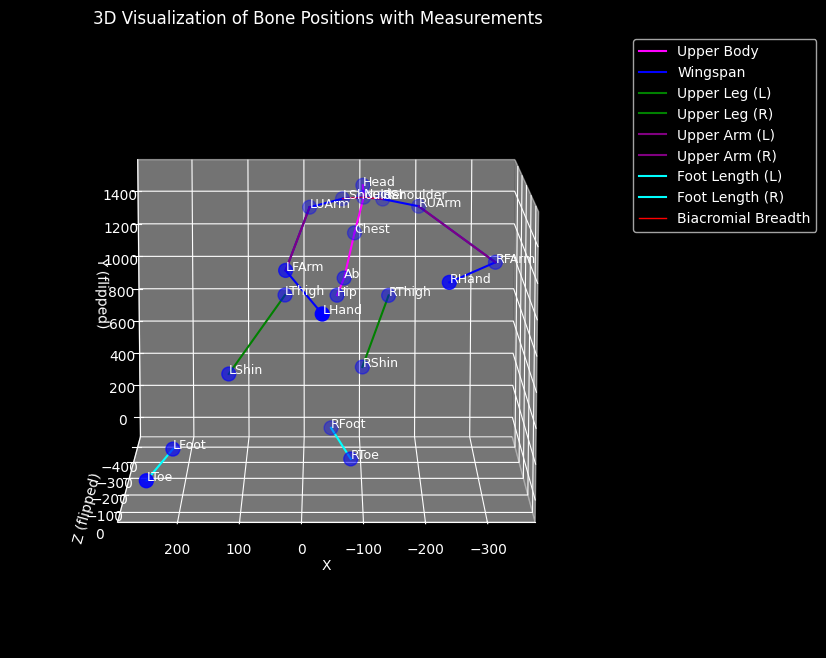

In [26]:
def calculate_distance(p1, p2):
    # Helper function to calculate distance between two points
    return ((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2) ** 0.5

def plot_full_measurements(frame_positions, bone_names):
    ...
    # Define the bone sequences for each measurement
    upper_body_bones = [
        f"{skeleton_identifier}:Head",
        f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:Chest",
        f"{skeleton_identifier}:Ab",
        f"{skeleton_identifier}:Hip"
    ]
    
    wingspan_bones_L = [
        f"{skeleton_identifier}:LHand",
        f"{skeleton_identifier}:LFArm",
        f"{skeleton_identifier}:LUArm",
        f"{skeleton_identifier}:LShoulder",
        f"{skeleton_identifier}:Neck"
    ]
    wingspan_bones_R = [
        f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:RShoulder",
        f"{skeleton_identifier}:RUArm",
        f"{skeleton_identifier}:RFArm",
        f"{skeleton_identifier}:RHand"
    ]
    upper_leg_bones_L = [
        f"{skeleton_identifier}:LThigh",
        f"{skeleton_identifier}:LShin"
    ]
    upper_leg_bones_R = [
        f"{skeleton_identifier}:RThigh",
        f"{skeleton_identifier}:RShin"
    ]
    
    upper_arm_bones_L = [
        f"{skeleton_identifier}:LUArm",
        f"{skeleton_identifier}:LFArm"
    ]
    upper_arm_bones_R = [
        f"{skeleton_identifier}:RUArm",
        f"{skeleton_identifier}:RFArm"
    ]

    foot_bones_L = [
        f"{skeleton_identifier}:LFoot",
        f"{skeleton_identifier}:LToe"
    ]
    foot_bones_R = [
        f"{skeleton_identifier}:RFoot",
        f"{skeleton_identifier}:RToe"
    ]
    biacromial_breadth_bones = [
        f"{skeleton_identifier}:LShoulder",
        f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:RShoulder",
    ]
    
    # Grouping for iteration
    measurement_groups = [
        (upper_body_bones, "magenta", "Upper Body", 1.5),
        (wingspan_bones_L + wingspan_bones_R, "blue", "Wingspan", 1.5),
        (upper_leg_bones_L, "green", "Upper Leg (L)", 1.5),
        (upper_leg_bones_R, "green", "Upper Leg (R)", 1.5),
        (upper_arm_bones_L, "purple", "Upper Arm (L)", 1.5),
        (upper_arm_bones_R, "purple", "Upper Arm (R)", 1.5),
        (foot_bones_L, "cyan", "Foot Length (L)", 1.5),
        (foot_bones_R, "cyan", "Foot Length (R)", 1.5)
    ]

    continuous_measurements = [
        # (upper_body_bones + upper_leg_bones_L, "green", "Standing Height", 1.0),
        (biacromial_breadth_bones, "red", "Biacromial Breadth", 1.0)
    ]

    # Extracting the X, Y, Z coordinates
    x_values = [pos[0] for pos in frame_positions]
    y_values = [pos[2] for pos in frame_positions]  # Flipping Y and Z
    z_values = [pos[1] for pos in frame_positions]  # Flipping Y and Z
    
    
    # Plotting the 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_values, y_values, z_values, c='blue', s=100)
    for i, bone_name in enumerate(bone_names):
        ax.text(x_values[i], y_values[i], z_values[i], bone_name.split(":")[-1], fontsize=9)


        # Draw Measurements
    for bones, color, label, lw in measurement_groups + continuous_measurements:
        for b1, b2 in zip(bones[:-1], bones[1:]):
            ax.plot([frame_positions[bone_names.index(b1)][0], frame_positions[bone_names.index(b2)][0]],
                    [frame_positions[bone_names.index(b1)][2], frame_positions[bone_names.index(b2)][2]],
                    [frame_positions[bone_names.index(b1)][1], frame_positions[bone_names.index(b2)][1]],
                    color=color, linewidth=lw, label=label)
    
    # Handling duplicates in legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1,1))


    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Z (flipped)')
    ax.set_zlabel('Y (flipped)')
    ax.view_init(azim=90, elev=10)  # Rotate view and set a more frontal perspective
    plt.title('3D Visualization of Bone Positions with Measurements')
    plt.show()

# Skeleton identifier (update according to your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Plotting the bone positions and measurements for the first frame
plot_full_measurements(frames_data[0], bone_names)


## Conclusion
This notebook provides a comprehensive toolset for auditing and analyzing skeletons generated from motion capture data. The functionalities include loading CSV files containing the skeleton data, extracting 3D positions, calculating specific measurements, and visualizing the bone positions.

### Comparing with Manual Measurements
To compare the calculated measurements with manual human measurements, you can load the manual data and analyze the differences using statistical methods or visual comparisons. The consistency and accuracy of the motion capture data can be assessed by identifying any significant deviations or patterns in the discrepancies.

### Next Steps
- **Customization**: Depending on the specific motion capture setup and requirements, you may need to customize the bone names, measurements, and coordinate system adjustments within this notebook.
- **Further Analysis**: Additional analyses can be performed to assess the stability, reliability, and accuracy of the motion capture data across different participants, sessions, or conditions.
- **Integration with Other Data**: The extracted bone positions and measurements can be integrated with other data sources (such as biomechanical analyses, behavioral observations, or subjective assessments) to provide a comprehensive understanding of the captured movements.
- **Automated Processing**: This notebook can be adapted into a script or automated pipeline to process multiple CSV files and generate summary reports or visualizations for large-scale analyses.

Feel free to explore, modify, and expand the content of this notebook to suit your specific needs and objectives. If you have any questions or encounter any issues, please consult the official documentation of the motion capture system or seek expert assistance.

Happy auditing and analyzing!
